In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

In [2]:
DP = DP()
dps_df, _, _, _ = DP.extract_fits_data('./catalogs/0428_dps_test.fits')

In [3]:
dps_df.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'DV_R', 'DV_L',
       'SIGMA_R', 'SIGMA_L', 'SIGMA_1COMP', 'P_VALUE', 'OII3726_FLUX_1COMP',
       'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP', 'OIII4959_FLUX_1COMP',
       'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP', 'SII6716_FLUX_1COMP', 'SII6731_FLUX_1COMP',
       'OII3726_FLUX_2COMP_L', 'OII3729_FLUX_2COMP_L', 'Hbeta_FLUX_2COMP_L',
       'OIII4959_FLUX_2COMP_L', 'OIII5007_FLUX_2COMP_L',
       'NII6548_FLUX_2COMP_L', 'Halpha_FLUX_2COMP_L', 'NII6583_FLUX_2COMP_L',
       'SII6716_FLUX_2COMP_L', 'SII6731_FLUX_2COMP_L', 'OII3726_FLUX_2COMP_R',
       'OII3729_FLUX_2COMP_R', 'Hbeta_FLUX_2COMP_R', 'OIII4959_FLUX_2COMP_R',
       'OIII5007_FLUX_2COMP_R', 'NII6548_FLUX_2COMP_R', 'Halpha_FLUX_2COMP_R',
       'NII6583_FLUX_2COMP_R', 'SII6716_FLUX_2COMP_R', 'SII6731_FLUX_2COMP_R',
       'OII3726_DP', 'OII3729_DP', 'Hbeta_DP', 'OIII4959_DP', 'OIII5007_DP',
       'NII6548_DP', 'Halpha_D

In [4]:
dps_df = dps_df[(dps_df['Halpha_SNR']>0) & (dps_df['Hbeta_SNR']>0) & (dps_df['LOGM']!=0) & (dps_df['LOGSFR_2COMP']>=-1)]

In [5]:
ebv_r = 1.97 * np.log10((dps_df['Halpha_FLUX_2COMP_R']/dps_df['Hbeta_FLUX_2COMP_R']) / 2.86)
A_halpha_r = 3.33 * ebv_r

ebv_l = 1.97 * np.log10((dps_df['Halpha_FLUX_2COMP_L']/dps_df['Hbeta_FLUX_2COMP_L']) / 2.86)
A_halpha_l = 3.33 * ebv_l

In [6]:
dps_df = dps_df[(A_halpha_r < np.inf) & (A_halpha_l < np.inf)]
A_halpha_r = A_halpha_r[(A_halpha_r < np.inf) & (A_halpha_l < np.inf)]
A_halpha_l = A_halpha_l[(A_halpha_r < np.inf) & (A_halpha_l < np.inf)]

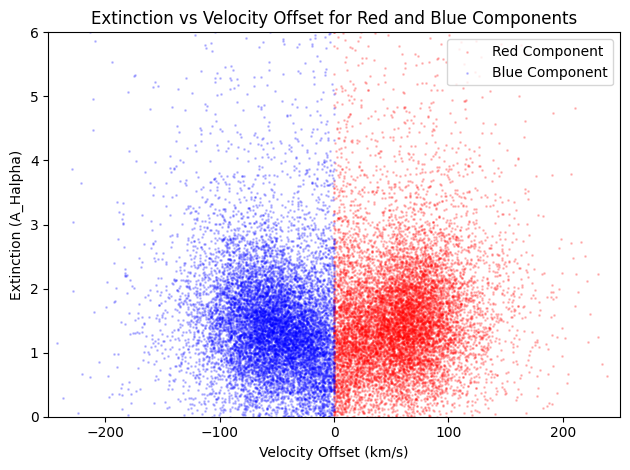

In [7]:
plt.scatter(dps_df['DV_R'], A_halpha_r, alpha=0.2, label='Red Component', color='r', s=1)
plt.scatter(dps_df['DV_L'], A_halpha_l, alpha=0.2, label='Blue Component', color='b', s=1)
plt.xlim(left=-250, right=250)
plt.ylim(bottom=0, top=6)
plt.xlabel('Velocity Offset (km/s)')
plt.ylabel('Extinction (A_Halpha)')
plt.legend()
plt.title('Extinction vs Velocity Offset for Red and Blue Components')
plt.tight_layout()
# plt.savefig('./figures/Apr23/extinction.png')
plt.show()

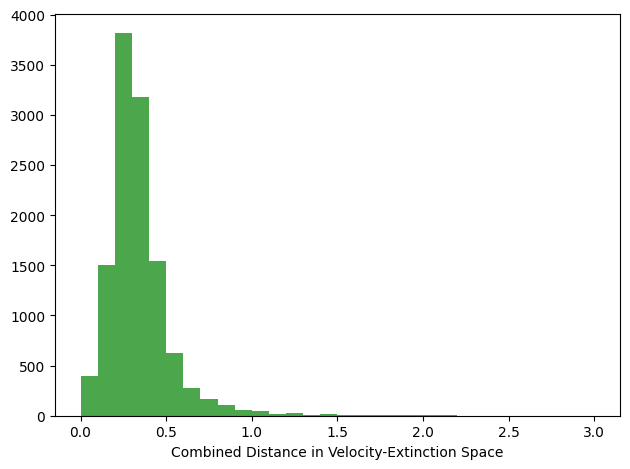

In [8]:
plt.hist(np.sqrt(((dps_df['DV_R']-dps_df['DV_L'])/500)**2+((A_halpha_r-A_halpha_l)/6)**2), bins=30, alpha=0.7, color='g', range=(0, 3))
plt.xlabel('Combined Distance in Velocity-Extinction Space')
plt.tight_layout()
# plt.savefig('./figures/Apr23/extinction_distance_small.png')
plt.show()

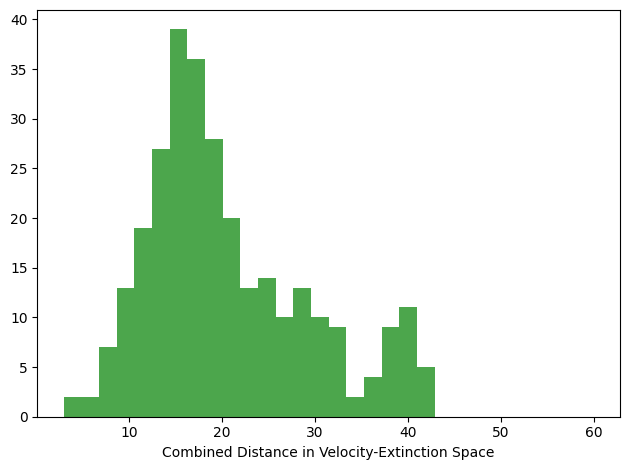

In [9]:
plt.hist(np.sqrt(((dps_df['DV_R']-dps_df['DV_L'])/500)**2+((A_halpha_r-A_halpha_l)/6)**2), bins=30, alpha=0.7, color='g', range=(3, 60))
plt.xlabel('Combined Distance in Velocity-Extinction Space')
plt.tight_layout()
# plt.savefig('./figures/Apr23/extinction_distance_large.png')
plt.show()

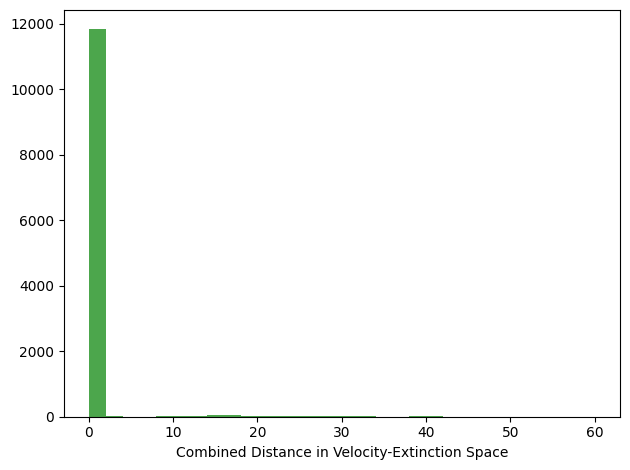

In [10]:
plt.hist(np.sqrt(((dps_df['DV_R']-dps_df['DV_L'])/500)**2+((A_halpha_r-A_halpha_l)/6)**2), bins=30, alpha=0.7, color='g', range=(0, 60))
plt.xlabel('Combined Distance in Velocity-Extinction Space')
plt.tight_layout()
plt.savefig('./figures/Apr23/extinction_distance.png')
plt.show()

In [11]:
majority_df = dps_df[np.sqrt(((dps_df['DV_R']-dps_df['DV_L'])/500)**2+((A_halpha_r-A_halpha_l)/6)**2) < 3].copy()
minority_df = dps_df[np.sqrt(((dps_df['DV_R']-dps_df['DV_L'])/500)**2+((A_halpha_r-A_halpha_l)/6)**2) >= 10].copy()

In [12]:
classification_map = {
    1: 'SF', 4: 'COMP', 16: 'AGN', 64: 'LINER', 256: 'unclassified',
    2: 'double SF', 8: 'double COMP', 32: 'double AGN', 128: 'double LINER',
    5: 'SF+COMP', 17: 'SF+AGN', 65: 'SF+LINER',
    20: 'COMP+AGN', 68: 'COMP+LINER', 80: 'AGN+LINER',
    257: 'SF+uncertain', 260: 'COMP+uncertain', 272: 'AGN+uncertain', 320: 'LINER+uncertain',
    512: 'unclassified'
}

In [13]:
majority_df['BPT_2COMP'] = majority_df['BPT_2COMP'].map(classification_map)
minority_df['BPT_2COMP'] = minority_df['BPT_2COMP'].map(classification_map)

In [14]:
majority_df.sort_values('dp_count', ascending=False).head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,NII6583_SNR,SII6716_SNR,SII6731_SNR,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count
19276,39627818069396498,187.408798,1.238466,0.163843,10.026310,0.648482,49.281548,-29.489679,28.941776,39.729862,...,29.875948,24.758131,18.614441,1,1,1,double SF,0.491242,0.623397,10
7911,39627770191415546,213.588333,-0.627301,0.121105,9.770502,0.554852,8.475651,-14.123042,61.567265,20.039040,...,34.224598,34.765026,25.062002,1,1,1,double SF,0.430791,0.424376,10
4224,39627757805635595,195.345825,-1.339311,0.087215,9.583420,0.291125,47.727146,-45.321430,44.854530,30.028961,...,23.180649,14.214768,8.863769,1,1,1,double SF,0.014630,0.057839,10
14785,39627799945806800,187.056900,0.616796,0.108200,10.205730,1.116597,73.995468,-84.580002,52.660172,47.442860,...,50.247612,23.776348,17.273138,1,1,1,double SF,0.800521,0.872815,10
11929,39627787954294029,192.445358,0.091490,0.121043,9.768531,0.505180,77.264709,-52.574562,59.529831,45.400814,...,13.710761,14.626379,10.434268,1,1,1,double SF,0.407816,0.442490,10
2863,39627751816168436,198.302246,-1.415033,0.246877,10.430558,1.315428,107.861336,-74.416664,54.281334,81.933289,...,29.104616,14.109738,10.170197,1,1,1,double SF,1.448346,1.533872,10
14089,39627794317050184,211.513916,0.343191,0.053576,9.442492,0.851394,5.344256,-12.269999,75.209778,26.640564,...,94.915131,68.079056,51.109280,1,1,1,double SF,0.367756,0.389719,10
7918,39627770195607806,213.757889,-0.754982,0.148204,9.587350,0.762990,39.841621,-54.441769,30.522474,30.395903,...,29.181419,19.632339,13.853372,1,1,1,double SF,0.642597,0.659088,10
13744,39627794149280054,201.616257,0.291919,0.103181,9.612188,0.496617,13.188055,-12.683130,0.001046,58.318459,...,21.954344,15.918932,12.361637,1,1,1,double SF,0.139668,-0.083267,10
10637,39627782031935024,199.345871,-0.246409,0.139778,9.147839,0.851507,8.111152,-4.868581,105.209198,46.797318,...,32.749966,21.381920,15.403635,1,1,1,double SF,0.628021,0.655244,10


In [15]:
print(majority_df['BPT_2COMP'].value_counts(normalize=True)*100)

BPT_2COMP
double SF         72.591404
SF+COMP           17.056489
double COMP        5.100059
SF+AGN             2.186946
COMP+AGN           0.945706
unclassified       0.844381
double AGN         0.835937
SF+LINER           0.177320
COMP+LINER         0.177320
AGN+LINER          0.067550
AGN+uncertain      0.008444
COMP+uncertain     0.008444
Name: proportion, dtype: float64


In [16]:
minority_df.sort_values('dp_count', ascending=False).head(40)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,DV_R,DV_L,SIGMA_R,SIGMA_L,...,NII6583_SNR,SII6716_SNR,SII6731_SNR,BPT_1COMP,BPT_2COMP_L,BPT_2COMP_R,BPT_2COMP,LOGSFR_1COMP,LOGSFR_2COMP,dp_count
19700,39627818308472490,201.672058,1.293263,0.193948,9.865299,0.483961,6.313656e+01,-2.255116e+01,26.936424,45.408012,...,11.637573,8.488742,5.986696,1,1,16,SF+AGN,0.363740,-0.061284,6
17798,39627812046376799,188.458221,1.082413,0.203759,10.301411,0.991479,6.418755e+01,-5.603539e+01,43.417683,46.857773,...,11.276941,10.400489,7.592193,1,1,16,SF+AGN,0.630065,0.316181,5
19808,39627818358802175,204.581406,1.192199,0.067249,10.236773,-0.005467,1.133838e+01,-7.059127e+00,27.995502,64.109039,...,20.774654,10.895827,8.566102,1,16,1,SF+AGN,0.095881,0.411395,5
20255,39627818581099005,217.767349,1.131783,0.107767,9.970394,0.575803,8.955173e+00,-2.569413e+01,41.270958,66.359917,...,11.807421,13.973288,7.841415,1,1,16,SF+AGN,0.176947,0.388400,4
5341,39627763618943736,181.964966,-1.025342,0.182178,9.781678,0.812407,1.022083e+01,-1.351105e+01,41.887280,73.890144,...,11.247981,10.047122,6.871319,1,1,16,SF+AGN,0.234579,0.100012,4
17807,39627812054763503,188.832077,0.978084,0.145577,9.157554,0.105121,6.610833e-02,-8.775838e-13,11.537501,60.774734,...,6.573329,6.983306,4.447187,1,16,1,SF+AGN,-0.428973,-0.818347,4
15833,39627800549785854,223.011078,0.528206,0.146973,9.958855,-0.421784,8.126837e+01,-4.230368e+01,34.655273,37.703609,...,10.694571,6.522845,3.886147,1,1,16,SF+AGN,0.140876,-0.577864,4
2508,39627751623232359,186.904526,-1.598680,0.094856,9.732993,-4.333501,1.057654e+01,-1.032111e+01,31.676058,64.659309,...,19.016932,14.759734,9.310319,1,16,1,SF+AGN,-0.293683,0.078491,4
17470,39627811907964911,180.197891,0.891353,0.211427,10.030565,0.508743,8.800524e+00,-1.711314e+01,35.292797,57.094002,...,11.582114,10.535486,8.059834,1,1,16,SF+AGN,0.077094,0.147991,4
17792,39627812046373234,188.269775,1.102723,0.268995,10.292702,0.894139,1.047401e+02,-5.333127e+01,31.332426,81.872620,...,5.984832,5.474509,4.116839,1,1,16,SF+AGN,0.623888,0.524202,3


In [17]:
print(minority_df['BPT_2COMP'].value_counts(normalize=True)*100)

BPT_2COMP
SF+AGN           79.710145
COMP+AGN          6.521739
double SF         5.797101
SF+COMP           3.623188
double AGN        1.811594
unclassified      1.086957
AGN+LINER         0.724638
AGN+uncertain     0.362319
double COMP       0.362319
Name: proportion, dtype: float64


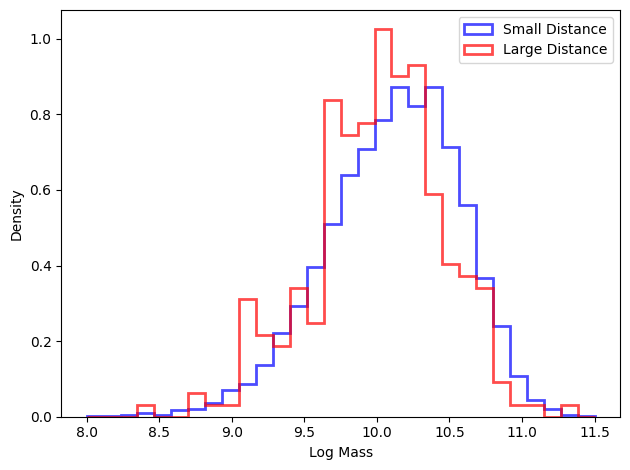

In [18]:
plt.hist(majority_df['LOGM'], bins=30, alpha=0.7, color='b', label='Small Distance', density=True, histtype='step', linewidth=2, range=(8,11.5))
plt.hist(minority_df['LOGM'], bins=30, alpha=0.7, color='r', label='Large Distance', density=True, histtype='step', linewidth=2, range=(8,11.5))
plt.xlabel('Log Mass')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Apr23/mass_hist.png')
plt.show()

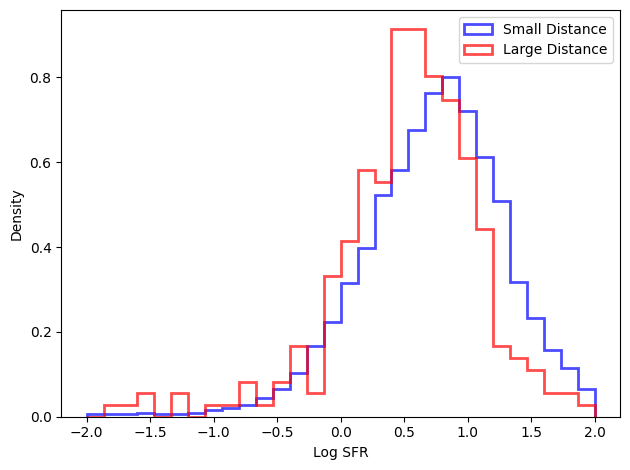

In [19]:
plt.hist(majority_df['LOGSFR'], bins=30, alpha=0.7, color='b', label='Small Distance', density=True, range=(-2, 2), histtype='step', linewidth=2)
plt.hist(minority_df['LOGSFR'], bins=30, alpha=0.7, color='r', label='Large Distance', density=True, range=(-2, 2), histtype='step', linewidth=2)
plt.xlabel('Log SFR')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Apr23/sfr_hist.png')
plt.show()

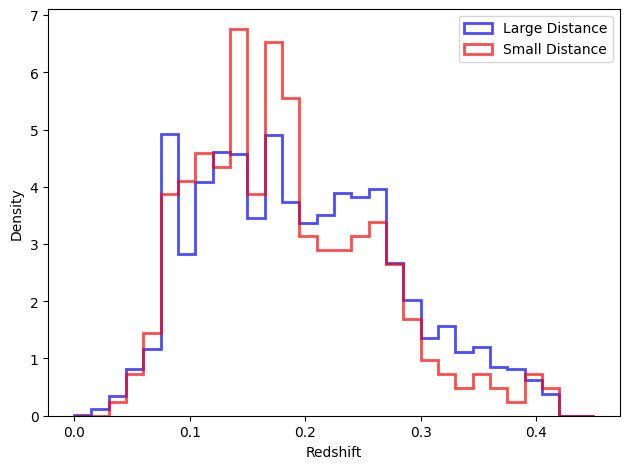

In [20]:
plt.hist(majority_df['Z'], bins=30, alpha=0.7, color='b', label='Large Distance', density=True, range=(0, 0.45), histtype='step', linewidth=2)
plt.hist(minority_df['Z'], bins=30, alpha=0.7, color='r', label='Small Distance', density=True, range=(0, 0.45), histtype='step', linewidth=2)
plt.xlabel('Redshift')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Apr23/redshift_hist.png')
plt.show()

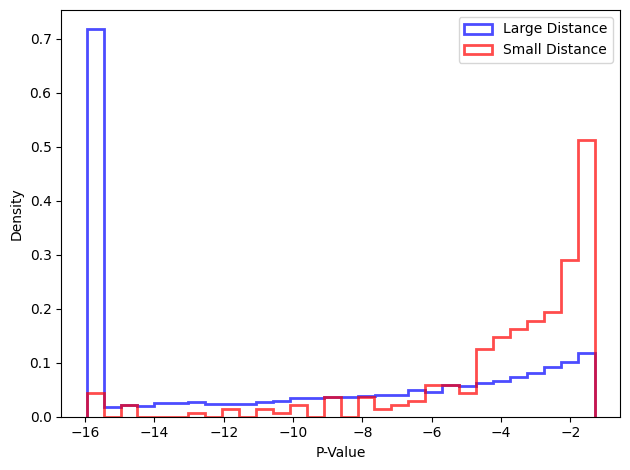

In [21]:
plt.hist(np.log10(majority_df['P_VALUE']), bins=30, alpha=0.7, color='b', label='Large Distance', density=True, histtype='step', linewidth=2)
plt.hist(np.log10(minority_df['P_VALUE']), bins=30, alpha=0.7, color='r', label='Small Distance', density=True, histtype='step', linewidth=2)
# plt.xscale('log')
plt.xlabel('P-Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

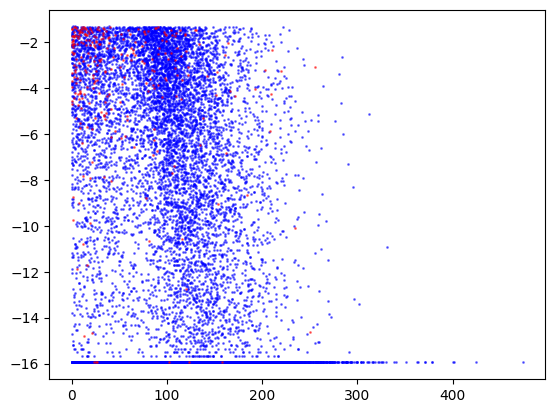

In [22]:
plt.scatter(majority_df['DV_R']-majority_df['DV_L'], np.log10(majority_df['P_VALUE']), alpha=0.5, color='b', label='Large Distance', s=1)
plt.scatter(minority_df['DV_R']-minority_df['DV_L'], np.log10(minority_df['P_VALUE']), alpha=0.5, color='r', label='Small Distance', s=1)
plt.show()